**In the foolwing code, we have used the algorithm: RANDOM FOREST for classification**

**Data Preparation**

    - Load datasets (df, test_df) and encode the "season" column.
    - Extract "Year" and "Month" from the "month" column.
    - Create pivot tables for precipitation data by month.

**Data Merging and Imputation**

    - Merge the most frequent season data based on "Longitude" and "Latitude."
    - Impute missing precipitation values using the mean.
    - Calculate total precipitation by summing monthly values.

**Rainfall Categorization and Feature Engineering**

    - Categorize rainfall into "Low," "Medium," and "High" based on quantiles.
    - Encode rainfall categories as numbers (0, 1, 2).
    - Select relevant features for training the model.

**Model Training and Evaluation**

    - Scale features using StandardScaler.
    - Train a Random Forest classifier on the training data.
    - Evaluate the model using accuracy, classification report, and confusion matrix.


Model Accuracy: 0.91

Classification Report:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97     25667
           1       0.41      0.52      0.46      2662
           2       1.00      0.78      0.88      9918

    accuracy                           0.91     38247
   macro avg       0.79      0.77      0.77     38247
weighted avg       0.92      0.91      0.91     38247



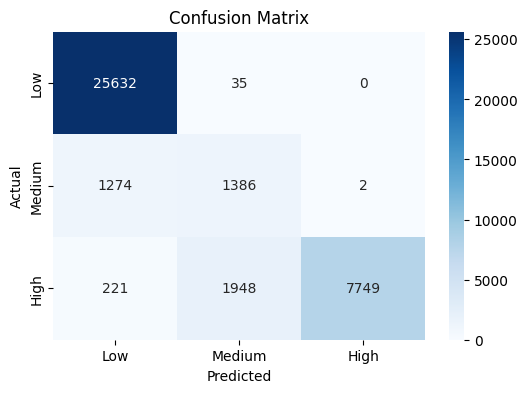

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer


df = pd.read_csv("DataSet.csv")
test_df = pd.read_csv("Test_DataSet.csv")


all_seasons = pd.concat([df['season'], test_df['season']]).unique()


season_encoder = LabelEncoder()
season_encoder.fit(all_seasons)

df["Season_Encoded"] = season_encoder.transform(df["season"])
test_df["Season_Encoded"] = season_encoder.transform(test_df["season"])


df["Year"] = df["month"].apply(lambda x: int(x.split("_")[1]))
df["Month"] = df["month"].apply(lambda x: int(x.split("_")[0]))
test_df["Year"] = test_df["month"].apply(lambda x: int(x.split("_")[1]))
test_df["Month"] = test_df["month"].apply(lambda x: int(x.split("_")[0]))


pivot_df = df.pivot_table(index=["Longitude", "Latitude"],
                         columns="Month",
                         values="Precipitation_Cleaned").reset_index()
train_months = sorted(df["Month"].unique())
pivot_df.columns = ["Longitude", "Latitude"] + [f"Month_{i}" for i in train_months]


test_pivot_df = test_df.pivot_table(index=["Longitude", "Latitude"],
                                   columns="Month",
                                   values="Precipitation_Cleaned").reset_index()
test_months = sorted(test_df["Month"].unique())
test_pivot_df.columns = ["Longitude", "Latitude"] + [f"Month_{i}" for i in test_months]


season_data = df.groupby(["Longitude", "Latitude"])["Season_Encoded"].agg(lambda x: x.mode()[0]).reset_index()
test_season_data = test_df.groupby(["Longitude", "Latitude"])["Season_Encoded"].agg(lambda x: x.mode()[0]).reset_index()

final_df = pivot_df.merge(season_data, on=["Longitude", "Latitude"])
final_test_df = test_pivot_df.merge(test_season_data, on=["Longitude", "Latitude"])


imputer = SimpleImputer(strategy='mean')
train_month_cols = [col for col in pivot_df.columns if col.startswith("Month_")]
test_month_cols = [col for col in test_pivot_df.columns if col.startswith("Month_")]
final_df[train_month_cols] = imputer.fit_transform(final_df[train_month_cols])
final_test_df[test_month_cols] = imputer.transform(final_test_df[test_month_cols])


final_df["Total_Precipitation"] = final_df[train_month_cols].sum(axis=1)
final_test_df["Total_Precipitation"] = final_test_df[test_month_cols].sum(axis=1)


low_threshold = final_df["Total_Precipitation"].quantile(0.33)
high_threshold = final_df["Total_Precipitation"].quantile(0.66)

def categorize_rainfall(value):
    if value <= low_threshold:
        return "Low Rainfall"
    elif value <= high_threshold:
        return "Medium Rainfall"
    else:
        return "High Rainfall"

final_df["Rainfall_Category"] = final_df["Total_Precipitation"].apply(categorize_rainfall)
final_test_df["Rainfall_Category"] = final_test_df["Total_Precipitation"].apply(categorize_rainfall)


category_mapping = {"Low Rainfall": 0, "Medium Rainfall": 1, "High Rainfall": 2}
final_df["Rainfall_Category"] = final_df["Rainfall_Category"].map(category_mapping)
final_test_df["Rainfall_Category"] = final_test_df["Rainfall_Category"].map(category_mapping)


common_features = ["Longitude", "Latitude", "Season_Encoded"] + list(set(train_month_cols) & set(test_month_cols))

X_train = final_df[common_features]
y_train = final_df["Rainfall_Category"]
X_test = final_test_df[common_features]
y_test = final_test_df["Rainfall_Category"]


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)


y_pred = rf_model.predict(X_test_scaled)


accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))


plt.figure(figsize=(6, 4))
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d",
            xticklabels=["Low", "Medium", "High"],
            yticklabels=["Low", "Medium", "High"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
